In [ ]:
# Сравнение алгоритмов кластеризации

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.decomposition import PCA

iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names
target_names = iris.target_names

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
def evaluate_clustering(model, X, y_true, model_name):
    labels = model.fit_predict(X)
    if len(set(labels)) > 1:  # silhouette требует минимум 2 кластера
        sil = silhouette_score(X, labels)
    else:
        sil = -1
    ari = adjusted_rand_score(y_true, labels)
    print(f"{model_name}: ARI = {ari:.3f}, Silhouette = {sil:.3f}, Кластеров = {len(set(labels))}")
    return labels, ari, sil

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_kmeans, ari_km, sil_km = evaluate_clustering(kmeans, X_scaled, y, "KMeans")

KMeans: ARI = 0.620, Silhouette = 0.460, Кластеров = 3


In [ ]:
agg = AgglomerativeClustering(n_clusters=3)
labels_agg, ari_agg, sil_agg = evaluate_clustering(agg, X_scaled, y, "Agglomerative")

Agglomerative: ARI = 0.615, Silhouette = 0.447, Кластеров = 3


In [ ]:
# Параметры подбираем примерно
dbscan = DBSCAN(eps=0.8, min_samples=3)
labels_db, ari_db, sil_db = evaluate_clustering(dbscan, X_scaled, y, "DBSCAN")

DBSCAN: ARI = 0.552, Silhouette = 0.522, Кластеров = 3


In [ ]:
gmm = GaussianMixture(n_components=3, random_state=42)
labels_gmm, ari_gmm, sil_gmm = evaluate_clustering(gmm, X_scaled, y, "GMM")

GMM: ARI = 0.516, Silhouette = 0.475, Кластеров = 3


In [ ]:
results = pd.DataFrame({
    'Algorithm': ['KMeans', 'Agglomerative', 'DBSCAN', 'GMM'],
    'ARI': [ari_km, ari_agg, ari_db, ari_gmm],
    'Silhouette': [sil_km, sil_agg, sil_db, sil_gmm]
})
print(results.sort_values('ARI', ascending=False).to_string(index=False))

    Algorithm      ARI  Silhouette
       KMeans 0.620135    0.459948
Agglomerative 0.615323    0.446689
       DBSCAN 0.551755    0.521697
          GMM 0.516459    0.475143


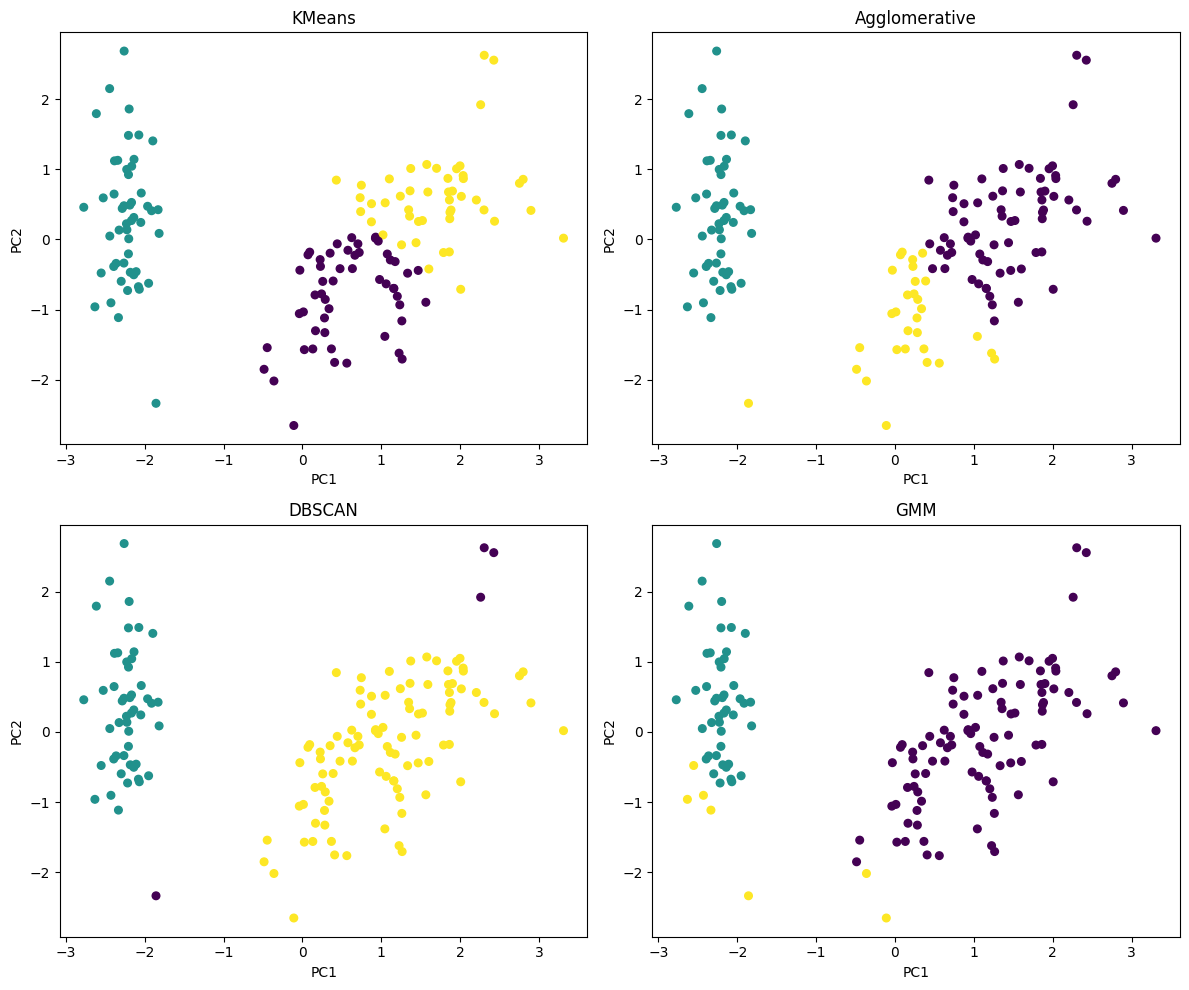

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, labels, title in zip(axes, [labels_kmeans, labels_agg, labels_db, labels_gmm],
                            ['KMeans', 'Agglomerative', 'DBSCAN', 'GMM']):
    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=30)
    ax.set_title(title)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
plt.tight_layout()
plt.show()